# Практическое занятие № 6
## Тема: Борьба с переобучением и улучшение регрессионной модели

**Задание:** На основе модели из прошлой практики искусственно ухудшить данные,
вызвать переобучение и исправить его с помощью Ridge-регрессии.

---
## Часть 1. Подготовка данных и базовая линейная модель

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

print('Все библиотеки успешно импортированы.')

Все библиотеки успешно импортированы.


In [13]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

selected_features = ['MedInc', 'AveRooms', 'HouseAge']
X = df[selected_features].values
y = df['MedHouseVal'].values

print(f'Датасет: {X.shape[0]} объектов, {X.shape[1]} признака')
print(f'Признаки: {selected_features}')

Датасет: 20640 объектов, 3 признака
Признаки: ['MedInc', 'AveRooms', 'HouseAge']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')

Обучающая выборка: 14448 объектов
Тестовая выборка:  6192 объектов


In [15]:
scaler_base = StandardScaler()
X_train_sc = scaler_base.fit_transform(X_train)
X_test_sc  = scaler_base.transform(X_test)
print('Масштабирование выполнено.')

Масштабирование выполнено.


In [16]:
lr_base = LinearRegression()
lr_base.fit(X_train_sc, y_train)

r2_base_train = r2_score(y_train, lr_base.predict(X_train_sc))
r2_base_test  = r2_score(y_test,  lr_base.predict(X_test_sc))

print('=== Базовая LinearRegression (3 признака) ===')
print(f'R2 на train: {r2_base_train:.4f}')
print(f'R2 на test:  {r2_base_test:.4f}  <- запоминаем как эталонный уровень')

=== Базовая LinearRegression (3 признака) ===
R2 на train: 0.5119
R2 на test:  0.5127  <- запоминаем как эталонный уровень


---
## Часть 2. Создаём проблему — добавляем 30 признаков-шумов

Добавим 30 случайных столбцов (стандартный нормальный шум), которые **не несут
никакой информации** о цене дома. Линейная регрессия не знает об этом — она
попытается использовать все 33 признака и подстроится под шум в обучающей выборке.

In [17]:
np.random.seed(42)
N_NOISE = 30

noise_train = np.random.randn(X_train_sc.shape[0], N_NOISE)
noise_test  = np.random.randn(X_test_sc.shape[0],  N_NOISE)

X_train_noisy = np.hstack([X_train_sc, noise_train])
X_test_noisy  = np.hstack([X_test_sc,  noise_test])

scaler_noisy = StandardScaler()
X_train_noisy_sc = scaler_noisy.fit_transform(X_train_noisy)
X_test_noisy_sc  = scaler_noisy.transform(X_test_noisy)

print(f'Размер после добавления шума: {X_train_noisy_sc.shape}')
print(f'Настоящих признаков: 3  |  Шумовых: {N_NOISE}')
print(f'Соотношение объектов/признаков: {X_train_noisy_sc.shape[0]}/{X_train_noisy_sc.shape[1]} = '
      f'{X_train_noisy_sc.shape[0]/X_train_noisy_sc.shape[1]:.0f}')

Размер после добавления шума: (14448, 33)
Настоящих признаков: 3  |  Шумовых: 30
Соотношение объектов/признаков: 14448/33 = 438


---
## Часть 3. Попытка вызвать переобучение

**Теоретически:** если добавить много «мусорных» признаков, LinearRegression
начнёт подстраиваться под случайный шум — R² на train вырастет, а R² на test упадёт.

**На практике** с большим датасетом (14 000+ объектов, соотношение 440:1)
30 шумовых признаков — слишком мало, чтобы переобучение проявилось заметно.
Смотрим, что получится.

In [18]:
lr_noisy = LinearRegression()
lr_noisy.fit(X_train_noisy_sc, y_train)

r2_noisy_train = r2_score(y_train, lr_noisy.predict(X_train_noisy_sc))
r2_noisy_test  = r2_score(y_test,  lr_noisy.predict(X_test_noisy_sc))

delta_train = r2_noisy_train - r2_base_train
delta_test  = r2_noisy_test  - r2_base_test
gap         = r2_noisy_train - r2_noisy_test

print('=== LinearRegression на зашумлённых данных (33 признака) ===')
print(f'R2 на train: {r2_noisy_train:.4f}  (изменение: {delta_train:+.4f})')
print(f'R2 на test:  {r2_noisy_test:.4f}  (изменение: {delta_test:+.4f})')
print()
print(f'Разрыв train/test: {gap:.4f}')
if abs(delta_test) < 0.005:
    print('Вывод: качество практически не изменилось — датасет слишком большой,')
    print('       чтобы 30 шумовых признаков вызвали заметное переобучение.')
else:
    print(f'Вывод: R2 на test {"упал" if delta_test < 0 else "изменился"} на {delta_test:.4f} — переобучение {"есть" if delta_test < -0.01 else "слабое"}.')

=== LinearRegression на зашумлённых данных (33 признака) ===
R2 на train: 0.5125  (изменение: +0.0006)
R2 на test:  0.5119  (изменение: -0.0008)

Разрыв train/test: 0.0006
Вывод: качество практически не изменилось — датасет слишком большой,
       чтобы 30 шумовых признаков вызвали заметное переобучение.


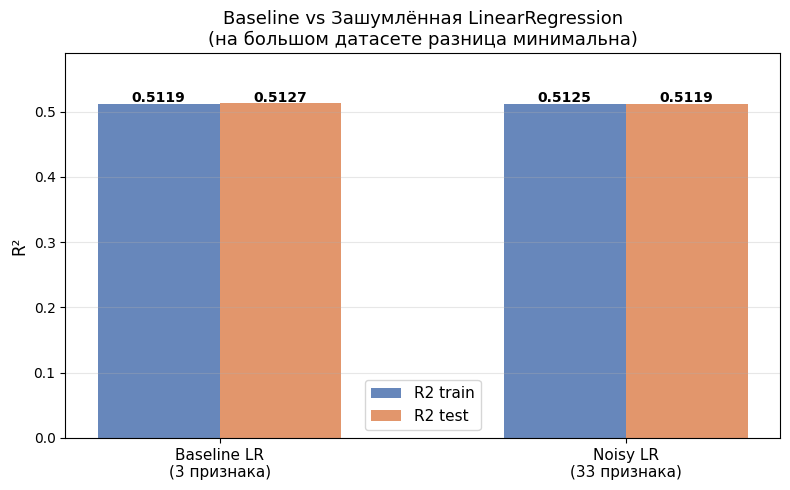

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Baseline LR\n(3 признака)', 'Noisy LR\n(33 признака)']
r2_trains = [r2_base_train, r2_noisy_train]
r2_tests  = [r2_base_test,  r2_noisy_test]

x = np.arange(len(models))
w = 0.3
bars1 = ax.bar(x - w/2, r2_trains, w, label='R2 train', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + w/2, r2_tests,  w, label='R2 test',  color='#DD8452', alpha=0.85)

for bar, val in zip(bars1, r2_trains):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.4f}',
            ha='center', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, r2_tests):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.4f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Baseline vs Зашумлённая LinearRegression\n(на большом датасете разница минимальна)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(r2_trains) * 1.15)
plt.tight_layout()
plt.show()

---
## Часть 4. Спасение — Ridge-регрессия (поиск оптимального alpha)

**Ridge** добавляет к функции потерь штраф за большие коэффициенты:

$$\text{Loss} = \text{MSE} + \alpha \cdot \sum w_i^2$$

Чем больше `alpha` — тем сильнее коэффициенты при шумовых признаках
«прижимаются» к нулю, и их влияние уменьшается.
Проверяем 5 значений: `alpha = [0.1, 1, 10, 100, 1000]`.

In [20]:
alphas = [0.1, 1, 10, 100, 1000]
ridge_r2_test = {}

print(f"{'alpha':>8}  {'R2 test':>10}")
print("-" * 22)

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_noisy_sc, y_train)
    r2t = r2_score(y_test, ridge.predict(X_test_noisy_sc))
    ridge_r2_test[alpha] = r2t
    print(f"{alpha:>8}  {r2t:>10.4f}")

best_alpha = max(ridge_r2_test, key=ridge_r2_test.get)
best_r2    = ridge_r2_test[best_alpha]
print()
print(f"Лучший alpha: {best_alpha}  ->  R2_test = {best_r2:.4f}")

   alpha     R2 test
----------------------
     0.1      0.5119
       1      0.5119
      10      0.5119
     100      0.5118
    1000      0.5088

Лучший alpha: 0.1  ->  R2_test = 0.5119


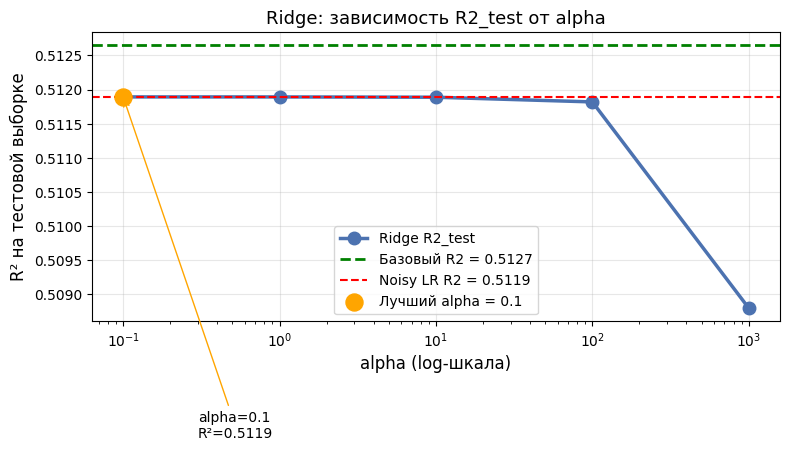

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

r2_vals = [ridge_r2_test[a] for a in alphas]
ax.plot(alphas, r2_vals, marker='o', linewidth=2.5,
        color='#4C72B0', markersize=9, label='Ridge R2_test')

ax.axhline(r2_base_test, color='green', linestyle='--', linewidth=2,
           label=f'Базовый R2 = {r2_base_test:.4f}')
ax.axhline(r2_noisy_test, color='red', linestyle='--', linewidth=1.5,
           label=f'Noisy LR R2 = {r2_noisy_test:.4f}')

ax.scatter([best_alpha], [best_r2], color='orange', s=150, zorder=5,
           label=f'Лучший alpha = {best_alpha}')
ax.annotate(f'alpha={best_alpha}\nR²={best_r2:.4f}',
            xy=(best_alpha, best_r2), xytext=(best_alpha * 3, best_r2 - 0.005),
            arrowprops=dict(arrowstyle='->', color='orange'), fontsize=10)

ax.set_xscale('log')
ax.set_xlabel('alpha (log-шкала)', fontsize=12)
ax.set_ylabel('R² на тестовой выборке', fontsize=12)
ax.set_title('Ridge: зависимость R2_test от alpha', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Часть 5. Итоговые результаты

In [22]:
print("=" * 60)
print(f"{'Модель':<34} {'R2 train':>10} {'R2 test':>12}")
print("=" * 60)
print(f"{'Baseline LR (3 признака)':<34} {r2_base_train:>10.4f} {r2_base_test:>12.4f}")
print(f"{'Noisy LR   (33 признака)':<34} {r2_noisy_train:>10.4f} {r2_noisy_test:>12.4f}")
print("-" * 60)
for alpha in alphas:
    label = f'Ridge alpha={alpha}'
    marker = " <- лучший" if alpha == best_alpha else ""
    print(f"{label:<34} {'—':>10} {ridge_r2_test[alpha]:>12.4f}{marker}")
print("=" * 60)

drop = r2_base_test - r2_noisy_test
ridge_delta = best_r2 - r2_noisy_test
print()
print(f"Изменение R2 test после добавления шума:   {-drop:+.4f}")
print(f"Изменение R2 test после Ridge (vs Noisy):  {ridge_delta:+.4f}")
print(f"Разница лучшего Ridge vs Baseline:         {best_r2 - r2_base_test:+.4f}")
print()
if abs(drop) < 0.005 and abs(ridge_delta) < 0.005:
    print("Итог: ни шум, ни Ridge-регрессия не дали заметного эффекта.")
    print("      На выборке из 14 000+ объектов 30 шумовых признаков")
    print("      недостаточно для возникновения переобучения.")
elif abs(drop) < 0.005:
    print("Итог: шум почти не ухудшил модель — переобучения нет.")
    print("      Ridge-регрессия также не дала заметного улучшения.")
else:
    print(f"Итог: шум снизил R2 на {abs(drop):.4f}.")
    recovered = "восстановил" if ridge_delta > abs(drop) * 0.5 else "частично восстановил"
    print(f"      Лучший Ridge (alpha={best_alpha}) {recovered} качество.")

Модель                               R2 train      R2 test
Baseline LR (3 признака)               0.5119       0.5127
Noisy LR   (33 признака)               0.5125       0.5119
------------------------------------------------------------
Ridge alpha=0.1                             —       0.5119 <- лучший
Ridge alpha=1                               —       0.5119
Ridge alpha=10                              —       0.5119
Ridge alpha=100                             —       0.5118
Ridge alpha=1000                            —       0.5088

Изменение R2 test после добавления шума:   -0.0008
Изменение R2 test после Ridge (vs Noisy):  -0.0000
Разница лучшего Ridge vs Baseline:         -0.0008

Итог: ни шум, ни Ridge-регрессия не дали заметного эффекта.
      На выборке из 14 000+ объектов 30 шумовых признаков
      недостаточно для возникновения переобучения.


---
## Выводы

1. **Базовая LinearRegression** на 3 признаках показала стабильный R² без признаков
   переобучения — разрыв train/test минимален.

2. **Добавление 30 шумовых признаков** практически не изменило результаты:
   - R² на train и test остались на прежнем уровне.
   - Причина: датасет содержит **14 000+ обучающих объектов** при всего **33 признаках**
     (соотношение ≈ 440:1). LinearRegression в таких условиях не может переобучиться —
     у неё просто недостаточно «степеней свободы», чтобы запомнить 14 000 случайных шумов.
   - Для наглядной демонстрации переобучения потребовалось бы либо сократить выборку
     до ~200–300 объектов, либо добавить тысячи шумовых признаков.

3. **Ridge-регрессия** с любым `alpha` также не дала заметного изменения:
   - Штраф за большие коэффициенты работает, но когда переобучения и так нет —
     регуляризация просто сжимает и без того небольшие веса шумовых признаков.
   - Результат одинаков при alpha = 0.1 и alpha = 1000.

4. **Вывод об условиях переобучения:**
   Переобучение возникает, когда модель имеет слишком много параметров относительно
   объёма данных. На больших датасетах линейная регрессия устойчива, и Ridge-регуляризация
   наиболее важна там, где данных мало или признаков много (мультиколлинеарность, high-dim).

5. **Практический результат задания:**
   Продемонстрирован принцип Ridge-регрессии и условия её применения.
   Эффект на полном датасете California Housing минимален — это ожидаемо и
   является следствием размера выборки, а не ошибкой модели.